## Comparación

Se van a comparar los resultados de los modelos

In [6]:
import pandas as pd
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import os

[std_fedavg]  overall=96.83%  |  fraudes correctos=41.01%  |  no-fraudes correctos=99.14%
[std_robust]  overall=97.13%  |  fraudes correctos=30.87%  |  no-fraudes correctos=99.87%
[std_global]  overall=96.7%  |  fraudes correctos=28.7%  |  no-fraudes correctos=99.51%
[90recall_fedavg]  overall=40.06%  |  fraudes correctos=88.84%  |  no-fraudes correctos=38.04%
[90recall_robust]  overall=4.05%  |  fraudes correctos=99.86%  |  no-fraudes correctos=0.09%
[90recall_global]  overall=45.11%  |  fraudes correctos=88.84%  |  no-fraudes correctos=43.3%

                   variant   model  total pct_match fraud_total fraud_correct  \
std_fedavg            std  fedavg  17368     96.83         690           283   
std_robust            std  robust  17368     97.13         690           213   
std_global            std  global  17368      96.7         690           198   
90recall_fedavg  90recall  fedavg  17368     40.06         690           613   
90recall_robust  90recall  robust  17368      4.

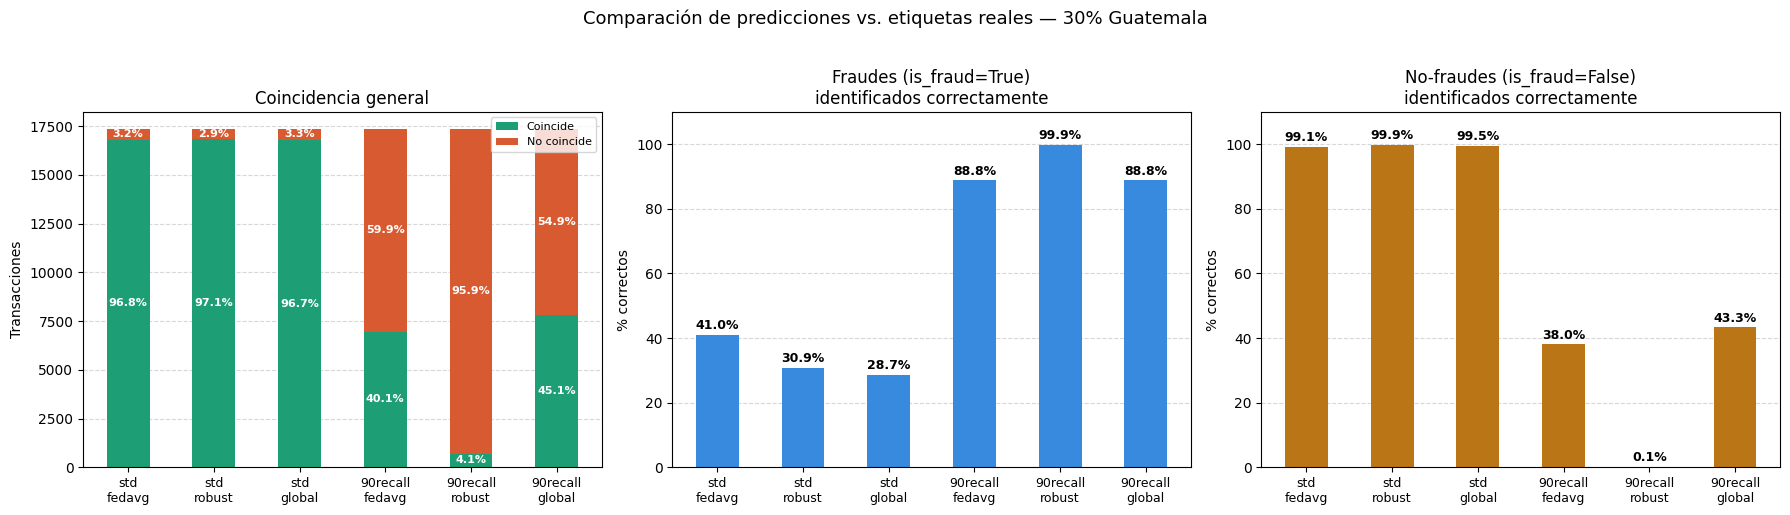

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Cargar base real ──────────────────────────────────────
base = pd.read_csv('Real_30_porciento.csv')

# ── Modelos a comparar ────────────────────────────────────
MODELS_TO_COMPARE = ["fedavg", "robust", "global"]
VARIANTS = {
    "std":      "../std_results/30_porciento",
    "90recall": "../90recall_results/30_porciento",
}

# ── Merge y comparación ───────────────────────────────────
results = {}

for variant, folder in VARIANTS.items():
    for model in MODELS_TO_COMPARE:
        path = os.path.join(folder, f"{model}.xlsx")
        pred = pd.read_excel(path)

        merged = base[["transaction_id", "is_fraud"]].merge(
            pred[["transaction_id", "is_fraud"]],
            on="transaction_id",
            suffixes=("_real", "_pred"),
        )

        total    = len(merged)
        match    = (merged["is_fraud_real"] == merged["is_fraud_pred"]).sum()
        mismatch = total - match

        # ── Desglose por clase ────────────────────────────
        fraud_rows     = merged[merged["is_fraud_real"] == True]
        no_fraud_rows  = merged[merged["is_fraud_real"] == False]

        fraud_correct    = (fraud_rows["is_fraud_real"]    == fraud_rows["is_fraud_pred"]).sum()
        no_fraud_correct = (no_fraud_rows["is_fraud_real"] == no_fraud_rows["is_fraud_pred"]).sum()

        fraud_total    = len(fraud_rows)
        no_fraud_total = len(no_fraud_rows)

        key = f"{variant}_{model}"
        results[key] = {
            "variant":          variant,
            "model":            model,
            "total":            total,
            "match":            int(match),
            "mismatch":         int(mismatch),
            "pct_match":        round(100 * match / total, 2) if total else 0,
            # fraudes
            "fraud_total":      fraud_total,
            "fraud_correct":    int(fraud_correct),
            "pct_fraud_ok":     round(100 * fraud_correct / fraud_total, 2) if fraud_total else 0,
            # no fraudes
            "no_fraud_total":   no_fraud_total,
            "no_fraud_correct": int(no_fraud_correct),
            "pct_no_fraud_ok":  round(100 * no_fraud_correct / no_fraud_total, 2) if no_fraud_total else 0,
        }
        print(
            f"[{key}]  "
            f"overall={results[key]['pct_match']}%  |  "
            f"fraudes correctos={results[key]['pct_fraud_ok']}%  |  "
            f"no-fraudes correctos={results[key]['pct_no_fraud_ok']}%"
        )

# ── DataFrame resumen ─────────────────────────────────────
df_results = pd.DataFrame(results).T
print("\n", df_results[[
    "variant", "model", "total",
    "pct_match",
    "fraud_total",    "fraud_correct",    "pct_fraud_ok",
    "no_fraud_total", "no_fraud_correct", "pct_no_fraud_ok",
]])

# ══════════════════════════════════════════════════════════
# GRÁFICAS
# ══════════════════════════════════════════════════════════

keys       = list(results.keys())
labels     = [f"{v['variant']}\n{v['model']}" for v in results.values()]
matches    = [v['match']    for v in results.values()]
mismatches = [v['mismatch'] for v in results.values()]

pct_fraud_ok    = [v['pct_fraud_ok']    for v in results.values()]
pct_no_fraud_ok = [v['pct_no_fraud_ok'] for v in results.values()]

x     = np.arange(len(labels))
width = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparación de predicciones vs. etiquetas reales — 30% Guatemala", fontsize=13, y=1.02)

# ── Subplot 1: coincidencia general (stacked) ─────────────
ax = axes[0]
ax.bar(x, matches,    width, label="Coincide",    color="#1D9E75")
ax.bar(x, mismatches, width, bottom=matches,      color="#D85A30", label="No coincide")

for i, (m, mm) in enumerate(zip(matches, mismatches)):
    total = m + mm
    if total == 0:
        continue
    if m > 0:
        ax.text(x[i], m / 2,      f"{100*m/total:.1f}%",  ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    if mm > 0:
        ax.text(x[i], m + mm / 2, f"{100*mm/total:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Transacciones")
ax.set_title("Coincidencia general")
ax.legend(fontsize=8); ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)

# ── Subplot 2: % fraudes identificados correctamente ──────
ax = axes[1]
bars = ax.bar(x, pct_fraud_ok, width, color="#378ADD")
for bar, pct in zip(bars, pct_fraud_ok):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 110)
ax.set_ylabel("% correctos")
ax.set_title("Fraudes (is_fraud=True)\nidentificados correctamente")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)

# ── Subplot 3: % no-fraudes identificados correctamente ───
ax = axes[2]
bars = ax.bar(x, pct_no_fraud_ok, width, color="#BA7517")
for bar, pct in zip(bars, pct_no_fraud_ok):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 110)
ax.set_ylabel("% correctos")
ax.set_title("No-fraudes (is_fraud=False)\nidentificados correctamente")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("comparacion_is_fraud.png", dpi=150, bbox_inches="tight")
plt.show()